In [1]:
import string # from some string manipulation tasks
import nltk # natural language toolkit
import re # regex
from string import punctuation # solving punctuation problems
from nltk.corpus import stopwords # stop words in sentences
from nltk.stem import WordNetLemmatizer # For stemming the sentence
from nltk.stem import SnowballStemmer # For stemming the sentence
from contractions import contractions_dict # to solve contractions
from autocorrect import Speller #correcting the spellings
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')

#Libraries for general purpose
import matplotlib.pyplot as plt
import seaborn as sns


#Data preprocessing
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

#Naive Bayes
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Samson\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Samson\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Samson\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv('./cleaned_cyberbullying_tweets.csv')
df['sentiment_encoded'].value_counts()

sentiment_encoded
5    7888
0    7808
1    7697
2    7318
3    6315
Name: count, dtype: int64

In [3]:
df.head()

,text_clean,sentiment_encoded
0,word katandandre food crapilicious mkr,3
1,aussietv white mkr theblock imacelebrityau tod...,3
2,classy whore red velvet cupcake,3
3,meh thanks head concerned another angry dude t...,3
4,isi account pretending kurdish account like is...,3


Model Training

In [7]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB  # Import the Multinomial Naive Bayes classifier
from sklearn.pipeline import Pipeline
import joblib

# Define the input and target variables
X = df['text_clean']
y = df['sentiment_encoded']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline that first vectorizes the text and then applies the Naive Bayes classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Converts text to TF-IDF features
    ('nb', MultinomialNB())  # Multinomial Naive Bayes classifier
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Save the model to a file
joblib.dump(pipeline, 'naive_bayes_model.pkl')

# # Optionally, print the accuracy of the model on the test set
# accuracy = pipeline.score(X_test, y_test)
# print(f'Accuracy on test set: {accuracy:.4f}')

['naive_bayes_model.pkl']

Multinomial Naive Bayes Model Evaluation

In [8]:
# Load the saved model from file
loaded_model = joblib.load('naive_bayes_model.pkl')

Classification Report

In [9]:
from sklearn.metrics import classification_report


# Assuming X_test and y_test are already defined in your environment:
y_pred = loaded_model.predict(X_test)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.98      0.86      1552
           1       0.89      0.92      0.91      1538
           2       0.87      0.87      0.87      1459
           3       0.86      0.39      0.54      1291
           5       0.84      0.97      0.90      1566

    accuracy                           0.84      7406
   macro avg       0.85      0.83      0.82      7406
weighted avg       0.85      0.84      0.82      7406



Confusion Matrix

Confusion Matrix:
[[1528    4    7    2   11]
 [  69 1411    5    3   50]
 [  40   46 1263   68   42]
 [ 332  106  163  506  184]
 [  16   12   14    7 1517]]


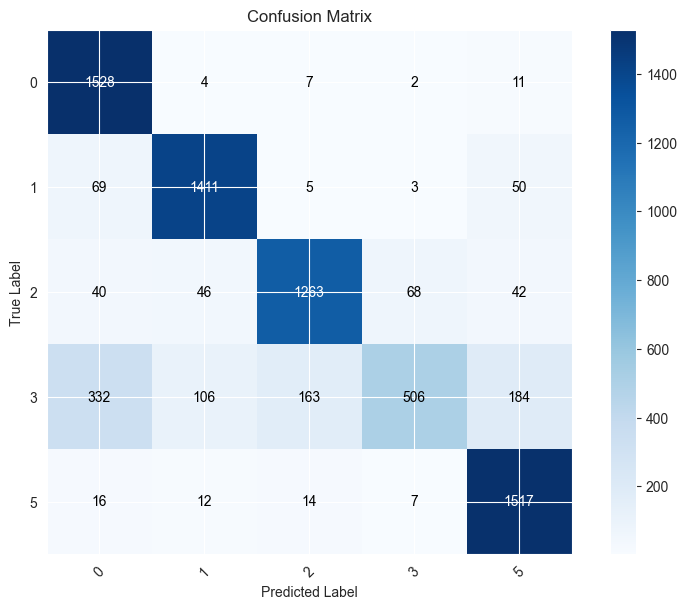

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate and print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Annotate each cell with its value
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Cross Validation Score

In [11]:
from sklearn.model_selection import cross_val_score

# If you have your full dataset (X and y) available, perform cross-validation
cv_scores = cross_val_score(loaded_model, X, y, cv=5)
print("Cross Validation Scores:")
print(cv_scores)
print("Mean Cross Validation Score:", cv_scores.mean())

Cross Validation Scores:
[0.83931947 0.83565159 0.84078325 0.83848751 0.83902768]
Mean Cross Validation Score: 0.838653900892081


Prediction

In [6]:
import joblib

# 1. Load the saved model
loaded_model = joblib.load('naive_bayes_model.pkl')

# 2. Define a new piece of text to classify
new_text = "I like your content. Keep up the good work!"

# 3. Predict the sentiment
prediction = loaded_model.predict([new_text])

# 4. Print the result
print(f"Text: {new_text}")
print(f"Predicted Sentiment: {prediction[0]}")

Text: I like your content. Keep up the good work!
Predicted Sentiment: 3


Hyperparameter Tuning with GridSearchCV

In [11]:
# Define the hyperparameter grid for GridSearchCV
param_grid = {
    'tfidf__max_df': [0.7, 0.8, 0.9, 1.0],         # TF-IDF max document frequency
    'tfidf__min_df': [1, 2, 5],                     # TF-IDF min document frequency
    'tfidf__ngram_range': [(1, 1), (1, 2)],         # Unigrams and bigrams
    'nb__alpha': [0.1, 0.5, 1.0, 1.5, 2.0],        # Smoothing parameter for Multinomial Naive Bayes
    'nb__fit_prior': [True, False]                  # Whether to use class prior probabilities
}

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    pipeline,           # The previously defined pipeline
    param_grid,                  # Hyperparameter grid to search over
    cv=5,                        # 5-fold cross-validation
    n_jobs=-1,                   # Use all available cores for faster computation
    verbose=1                    # Print detailed output during grid search
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and the best cross-validation score
print("Best parameters from GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score (GridSearchCV):", grid_search.best_score_)

# Save the best model from GridSearchCV
joblib.dump(grid_search.best_estimator_, 'naive_bayes_best_grid.pkl')

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best parameters from GridSearchCV: {'nb__alpha': 0.5, 'nb__fit_prior': False, 'tfidf__max_df': 0.7, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best cross-validation score (GridSearchCV): 0.8787305874409185


Hyperparameter Tuning with RandomizedSearchCV

In [15]:
from scipy.stats import uniform

# Define the hyperparameter distribution for RandomizedSearchCV
param_dist = {
    'tfidf__max_df': uniform(0.7, 0.3),             # Randomize the max document frequency between 0.7 and 1.0
    'tfidf__min_df': [1, 2, 5],                      # Discrete values for min document frequency
    'tfidf__ngram_range': [(1, 1), (1, 2)],          # Unigrams and bigrams
    'nb__alpha': uniform(0.1, 2.0),                  # Randomize smoothing parameter between 0.1 and 2.0
    'nb__fit_prior': [True, False]                   # Discrete values for whether to use class prior probabilities
}

# Set up RandomizedSearchCV with 5-fold cross-validation
random_search = RandomizedSearchCV(
    pipeline,              # The previously defined pipeline
    param_distributions=param_dist,  # Hyperparameter distribution to sample from
    n_iter=100,                     # Number of random combinations to sample
    cv=5,                           # 5-fold cross-validation
    n_jobs=-1,                      # Use all available cores for faster computation
    verbose=1                       # Print detailed output during random search
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Print the best hyperparameters and the best cross-validation score
print("Best parameters from RandomizedSearchCV:", random_search.best_params_)
print("Best cross-validation score (RandomizedSearchCV):", random_search.best_score_)


# Save the best model from RandomizedSearchCV
joblib.dump(random_search.best_estimator_, 'naive_bayes_best_random.pkl')

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters from RandomizedSearchCV: {'nb__alpha': np.float64(0.4216967611272361), 'nb__fit_prior': False, 'tfidf__max_df': np.float64(0.7589670512375636), 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best cross-validation score (RandomizedSearchCV): 0.8782916948008103


['naive_bayes_best_random.pkl']

Best Model Performance Evaluation

In [24]:
# Load the saved model from file
loaded_best_model = joblib.load('naive_bayes_best_grid.pkl')

Classification Report

In [25]:
from sklearn.metrics import classification_report


# Assuming X_test and y_test are already defined in your environment:
y_pred = loaded_best_model.predict(X_test)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1552
           1       0.92      0.94      0.93      1538
           2       0.90      0.85      0.87      1459
           3       0.79      0.60      0.68      1291
           5       0.87      0.96      0.91      1566

    accuracy                           0.87      7406
   macro avg       0.87      0.86      0.86      7406
weighted avg       0.87      0.87      0.87      7406



Confusion Matrix

Confusion Matrix:
[[1509    5    3   24   11]
 [  26 1441   11   29   31]
 [  17   40 1247  121   34]
 [ 177   71  120  769  154]
 [   5   11   12   27 1511]]


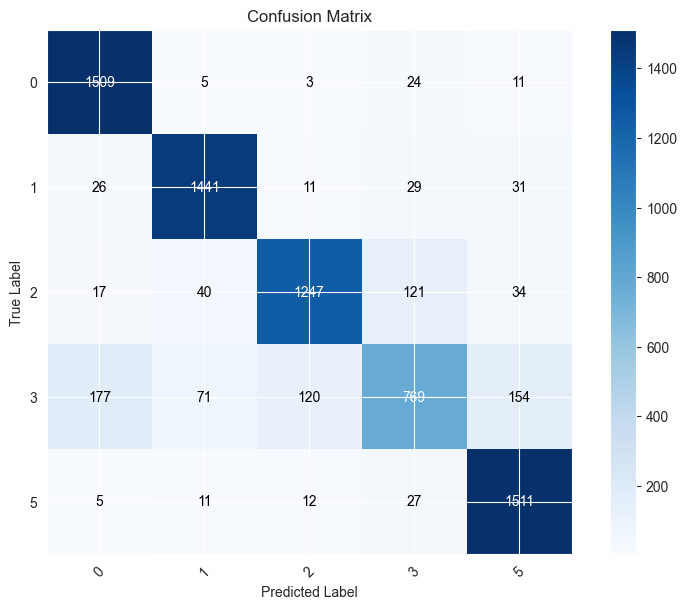

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate and print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Annotate each cell with its value
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Cross Validation Score

In [27]:
from sklearn.model_selection import cross_val_score

# If you have your full dataset (X and y) available, perform cross-validation
cv_scores = cross_val_score(loaded_model, X, y, cv=5)
print("Cross Validation Scores:")
print(cv_scores)
print("Mean Cross Validation Score:", cv_scores.mean())

Cross Validation Scores:
[0.87591142 0.87278866 0.8729237  0.87467927 0.87265361]
Mean Cross Validation Score: 0.8737913325746611


Prediction

In [28]:
import joblib

# 1. Load the saved model
loaded_model = joblib.load('naive_bayes_best_grid.pkl')

# 2. Define a new piece of text to classify
new_text = "I like your content. Keep up the good work!"

# 3. Predict the sentiment
prediction = loaded_model.predict([new_text])

# 4. Print the result
print(f"Text: {new_text}")
print(f"Predicted Sentiment: {prediction[0]}")

Text: I like your content. Keep up the good work!
Predicted Sentiment: 3
